In [1]:
from astropy.io import fits
from astropy.table import vstack
from photutils.detection import DAOStarFinder
import numpy as np
from scipy.optimize import curve_fit
from matplotlib import pyplot as plt
from ccdproc import ImageFileCollection
from multiprocessing import Pool
from functools import partial

from packages.imageauxiliary_functions import image_extensions
from packages.dataprocessing_functions import fwhm_fit

import warnings
from photutils.detection.daofinder import NoDetectionsWarning


In [ ]:
file = './data/2024-12-04/SO2024B-101_0412.168.fits'
# file = './data/2024-12-04/SO2024B-101_0412.212.fits'

with fits.open(file) as hdul:
    image = hdul[0].data
    header = hdul[0].header

    tab = fwhm_fit(image,fwhm_estimate=20.)
    nfit = np.sum(np.isfinite(tab['fwhm']))
    print(nfit,np.nanmedian(tab['fwhm']))

    # initial_fwhm = 40
    # half_box = initial_fwhm

    # #.Using sigma-clipping to model the background
    # # (actually, replaced by simple median and MAD for speed)
    # back_median = np.nanmedian(image)
    # back_std = 1.4826*np.nanmedian(np.abs(image-back_median))

    # #.Detecting sources using IRAFStarfinder method
    # # (actually, DAOFinder is faster than IRAFStarFinder)
    # # (find_peaks is even faster, but unreliable)
    # daofinder = DAOStarFinder(10*back_std, initial_fwhm,
    #                         roundlo=-2.0, roundhi=2.0, sharplo=0.01, sharphi=10.0,
    #                         brightest=None, exclude_border=False, peakmax=52000.)
    
    # #..catching zero objects warning and aborting
    # with warnings.catch_warnings():
    #     warnings.filterwarnings("error", category=NoDetectionsWarning)
    #     try:
    #         tab = daofinder.find_stars(image[half_box:-half_box,half_box:-half_box]-back_median)
    #         nstar = len(tab)
    #     except NoDetectionsWarning:
    #         nstar = 0
    # tab['xcentroid'] += half_box
    # tab['ycentroid'] += half_box
    # tab.sort('mag')

    # print(initial_fwhm,nstar)

    tab.pprint_all()    




14 28.42657517815718
    xcentroid          ycentroid           sharpness       roundness1        roundness2      npix    peak        flux         mag         daofind_mag            beta             major_ax           minor_ax          ellipticity            theta               fwhm               r50        
------------------ ------------------ ------------------- ------------ --------------------- ---- --------- ------------- ----------- ------------------- ------------------ ------------------ ------------------ ------------------- ------------------- ------------------ ------------------
 534.9942564656743 1741.3037226238318  0.5868748808064583 0.0047807707   0.29650162535322444  625 11353.918 3.6460408e+06  -16.404554  -7.863121901863593                nan                nan                nan                 nan                 nan                nan                nan
 526.7352187509533 1745.1881185298469   0.504238912818097    -0.210309 -0.000611605169624949  625 10773.169  3.4

In [2]:
def fwhm_estimate(dataset, multiprocessing=False, **kwargs):

    #.If input dataset is a folder, expand it into a ImageFileCollection
    if isinstance(dataset,str): 
        ifc = ImageFileCollection(dataset, ext=0,
         keywords=['obstype','ut','ccdsum','airmass','exptime','object'],
         glob_exclude="*master*.fits, bpm*.fits", glob_include="*.fits")
    
    #.Otherwise the input dataset is already a ImageFileCollection
    else: ifc = dataset

    #.grouping SCIENCE images in a list 
    obj_ifc = ifc.filter(obstype='OBJECT', regex_match=True)
    obj_list = obj_ifc.files

    #.estimating FHWM for each image
    if multiprocessing: 
        with Pool() as pool:
            pool.map(partial(fwhm_image, **kwargs), obj_list)
    else: 
        for file in obj_list: 
            fwhm_image(file)


def fwhm_image(file, image_area=0.33, is_hdu=False, **kwargs):

    if is_hdu: hdul=file
    else: hdul = fits.open(file, mode='update')

    #.looping over the image extensions
    image_indices = image_extensions(file, is_hdu=is_hdu)
    n_ext = len(image_indices)
    for ext in image_indices:
    
    #.initializing arguments
        img = hdul[ext].data
        hdr = hdul[ext].header

        if n_ext == 1:
            imsz = img.shape
            border = (1-image_area)/2
            data = img[round(border*imsz[0]):round((1-border)*imsz[0]),
                       round(border*imsz[1]):round((1-border)*imsz[1])]
        else: data = img
        
    #.calculating FWHM for this extension stars
        if ext == image_indices[0]: table = fwhm_fit(data, **kwargs)
        else: table = vstack([table,fwhm_fit(data, **kwargs)],metadata_conflicts='silent')
        
    #.if there are enough stars, skip to the end 
        good_data = np.isfinite(table['fwhm'])
        n_good = np.sum(good_data)
        if n_good >= 10: break
    
    #.getting best value for FWHM and storing in header
    if n_good > 0:
        fwhm = np.median(table['fwhm'][good_data])
        beta = np.median(table['beta'][good_data])
    else: fwhm, beta = 0, 0
    print(f".{file}: FWHM = {fwhm:.2f} ({n_good})")

    for ext in image_indices:
        hdul[ext].header.set("FWHM",fwhm,f"Moffat FWHM (median of {n_good} values)")
        hdul[ext].header.set("BETA",beta,f"Moffat Beta (median of {n_good} values)")
        hdul[ext].header.set("BACK",table.meta['back'],f"Median background value")
        hdul[ext].header.set("BACK_RMS",table.meta['back_rms'],f"Background std-dev (from MAD)")

    #.returning
    if is_hdu: return hdul
    else: 
        hdul.close()
        return table


def fwhm_fit(image, n_max=50, saturation=52430.):

    initial_fwhm = 10
    half_box = initial_fwhm

    #.Using sigma-clipping to model the background
    # (actually, replaced by simple median and MAD for speed)
    back_median = np.median(image)
    back_std = 1.4826*np.median(np.abs(image-back_median))

    #.Detecting sources using IRAFStarfinder method
    # (actually, DAOFinder is faster than IRAFStarFinder)
    # (find_peaks is even faster, but unreliable)
    daofinder = DAOStarFinder(3*back_std, 1.5*initial_fwhm,
                            roundlo=-2.0, roundhi=2.0, sharplo=0.01, sharphi=10.0,
                            brightest=n_max, exclude_border=False, peakmax=saturation)
    tab = daofinder.find_stars(image[half_box:-half_box,half_box:-half_box]-back_median)
    tab['xcentroid'] += half_box
    tab['ycentroid'] += half_box
    tab.sort('mag')

    #.Building a global pixel grid with 1-FWHM size
    pos_xy = np.arange(-half_box, half_box, 1)
    global_x, global_y = np.meshgrid(pos_xy, pos_xy)
    params, parerr = np.full((n_max,5), np.nan), np.full((n_max,5), np.nan)

    for i,row in enumerate(tab):

        #.Adjusting grid for this star
        xcen, ycen = round(row['xcentroid']), round(row['ycentroid'])
        grid_x = global_x + xcen
        grid_y = global_y + ycen

        #.Fitting 2D model with curve_fit
        datax = np.vstack((grid_x.ravel(),grid_y.ravel())).astype(float)
        datay = image[ycen-half_box:ycen+half_box, xcen-half_box:xcen+half_box].ravel()-back_median
        datay = datay.clip(min=1)
        erroy = np.sqrt(datay)
        p0 = [row['peak'],xcen,ycen,10,3.5]
        try:
            popt, pcov = curve_fit(moffat2d, datax[:,:], datay[:],p0=p0,
                                sigma=erroy[:], absolute_sigma=True)
        except RuntimeError:
            continue

        #..gathering resulting coefficients
        perr = np.sqrt(np.diag(pcov))
        params[i,:] = popt
        parerr[i,:] = perr/popt
    
    #.composing output table
    mask = (parerr[:,3] > 1) | (parerr[:,4] > 1) | (params[:,4] <= 1)
    params[mask,:] = np.nan
    parerr[mask,:] = np.nan

    tab['fwhm'] = 2*abs(params[:,3])*np.sqrt(2**(1/params[:,4])-1)
    tab['beta'] = params[:,4]
    tab.meta = {'back': back_median, 'back_rms': back_std}
    tab.remove_column('id')

    return tab


def moffat2d(xy,I,x0,y0,a,b):
    """
    Definition of the two-dimensional Moffat intensity profile:
    
    f(r) = I * ( 1 + ((x-x0)/a)^2 + ((y-y0)/a)^2 )^-b

    where   x, y are the data pixel coordinates
            f(r) is the data intensity at each coordinate 
            x0, y0 are the source peak (centre) pixel coordinates
            I is the central intensity.
                for PDF normalization: I = (b-1)/(pi*a^2)
            a is the Moffat characteristic radius
                FWHM = 2.a.sqrt(2^(1/b) - 1)   - seeing
                r_50 = a.sqrt(2^(1/(b-1)) -1)  - half flux radius
            b is the Moffat characteristic exponent (~2.5-4.0)

    Arguments
    ---------
        (x,y) : 2D-array (2 x N)
            X, Y pixel coordinates of the source data
        x0, y0: float
            souce peak (centre) pixel coordinates
        I : float
            maximum intensity (central value) of the profile
        a : float
            Moffat characteristic radius of the profile.
        b : float
            Moffat characteristic exponent. For stellar objects it usually 
            falls in the 2.5-4.0 range. 

    Returns
    -------
        intensities : 1D-array
            the program will return a array of the calculated intensities at
            each supplied radius            
    """
    x, y = xy
    return I*( 1 + ((x-x0)/a)**2 + ((y-y0)/a)**2 )**(-b)


In [1]:
from dataprocessing_functions import fwhm_estimate
folder = './20210710/'
fwhm_estimate(folder,multiprocessing=True)

../20210710/SO2021A-002.065.fits: FWHM = 7.68 (49)../20210710/SO2021A-002.071.fits: FWHM = 7.13 (49)
../20210710/SO2021A-002.086.fits: FWHM = 9.09 (48)
../20210710/SO2021A-002.068.fits: FWHM = 6.70 (49)
../20210710/SO2021A-002.080.fits: FWHM = 8.21 (48)

../20210710/SO2021A-002.074.fits: FWHM = 6.23 (49)
../20210710/SO2021A-002.077.fits: FWHM = 9.12 (49)
../20210710/SO2021A-002.092.fits: FWHM = 6.64 (47)../20210710/SO2021A-002.089.fits: FWHM = 8.26 (47)

../20210710/SO2021A-002.110.fits: FWHM = 8.40 (41)
../20210710/SO2021A-002.083.fits: FWHM = 8.70 (48)
../20210710/SO2021A-002.098.fits: FWHM = 8.99 (42)../20210710/SO2021A-002.095.fits: FWHM = 6.89 (47)

../20210710/SO2021A-002.131.fits: FWHM = 6.05 (26)
../20210710/SO2021A-002.137.fits: FWHM = 5.87 (25)
../20210710/SO2021A-002.143.fits: FWHM = 6.24 (25)
../20210710/SO2021A-002.107.fits: FWHM = 9.16 (41)
../20210710/SO2021A-002.140.fits: FWHM = 6.16 (24)../20210710/SO2021A-002.146.fits: FWHM = 5.86 (25)

../20210710/SO2021A-002.119.fit

In [5]:
file = './20210710/SO2021A-002.382.fits'
tab = fwhm_image(file)


../20210710/SO2021A-002.382.fits: FWHM = 10.30 (7)


In [4]:
tab

xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,sky,peak,flux,mag,fwhm,beta
float64,float64,float64,float32,float64,int64,float64,float64,float64,float64,float64,float64
493.49254423704616,380.4076178746293,0.45978682729731535,-0.10656167,-0.4386624380227289,361,0.0,289.8125305175781,143.22227478027344,-5.390026418216163,11.607713813132683,6.722305971333587
267.0436453746948,296.8579285479513,0.7120518330363537,-0.121179625,-0.35225253619894237,361,0.0,50.214683532714844,19.414072036743164,-3.220291591898275,nan,nan
239.65506127045063,559.4884298369548,0.5658942400838048,-0.113365516,-0.39763663202972316,361,0.0,36.13792419433594,15.813780784606934,-2.997589285455682,nan,nan
41.783388453800356,178.13150659259244,0.3600622378030135,-0.10979266,-0.45331823933086646,361,0.0,25.830799102783203,14.509556770324707,-2.904135365149778,10.6508896994054,6.063911076265552
46.544331534699445,599.769895204654,0.7262503714518949,-0.07099577,-0.43992782282690196,361,0.0,37.41386032104492,13.95904541015625,-2.862139300145399,11.538793859924311,7.700564691244408
325.92739868562904,107.78227134930196,0.3465421512355451,-0.12168652,-0.32883618379293694,361,0.0,23.217891693115234,13.506166458129883,-2.8263302448097702,10.298526745547768,7.808819471563809
523.4780571314888,651.2647203925745,0.7732642776090215,0.0026338268,-0.47679244376406715,361,0.0,29.223424911499023,10.73783016204834,-2.5772913263476753,9.734048592360137,3.8689547389592396
531.0857852328581,85.95874333448202,0.44914818353264063,0.03771626,-0.34651005321067285,361,0.0,16.683107376098633,8.564908027648926,-2.3318067593807883,9.1344310972151,2.031758605590793
50.0007774434011,48.797166634150166,0.7569197231636238,0.093107894,-0.462518704431277,361,0.0,17.258338928222656,6.66883659362793,-2.0601251900996633,8.070089626595145,1.2525322073015437


Text(0.5, 0, 'Moffat Beta (pixel)')

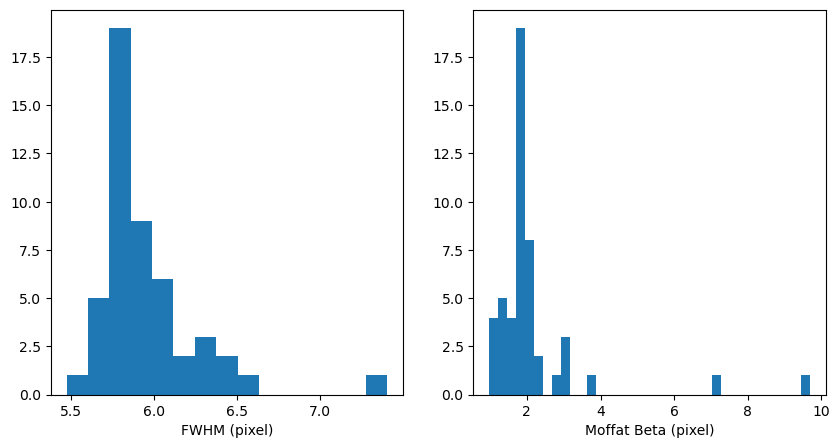

In [5]:
fig, [ax1,ax2] = plt.subplots(1,2,figsize=(10,5))
ax1.hist(tab['fwhm'],bins='fd')
ax1.set_xlabel('FWHM (pixel)')

ax2.hist(tab['beta'],bins='fd')
ax2.set_xlabel('Moffat Beta (pixel)')

In [1]:
import imexam
viewer=imexam.connect()

/home/kicage/.miniforge3/envs/imexam-env/lib/python3.9/site-packages/imexam/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Ginga not installed, use other viewer, or no viewer



Press 'q' to quit

2 Make the next plot in a new window
a Aperture sum, with radius region_size 
b Return the 2D gauss fit center of the object
c Return column plot
d Return the Center of Mass fit center of the object
e Return a contour plot in a region around the cursor
g Return curve of growth plot
h Return a histogram in the region around the cursor
j 1D [Gaussian1D default] line fit 
k 1D [Gaussian1D default] column fit
l Return line plot
m Square region stats, in [region_size],default is median
r Return the radial profile plot
s Save current figure to disk as [plot_name]
t Make a fits image cutout using pointer location
w Display a surface plot around the cursor location
x Return x,y,value of pixel
y Return x,y,value of pixel
Current image /data/SOAR/2021A/20211015/0353_SO2021B-203_1510.fits
Line at 688 818


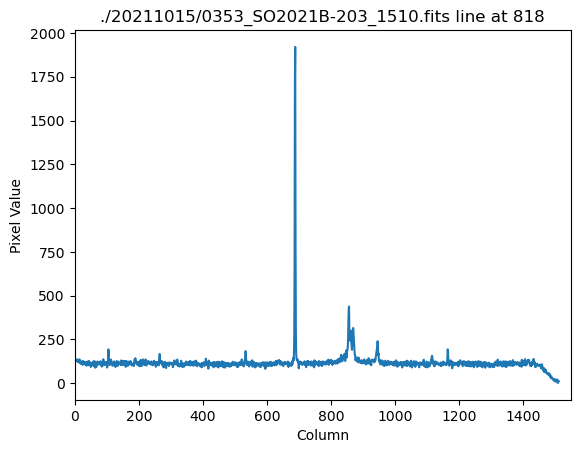

Column at 688 818


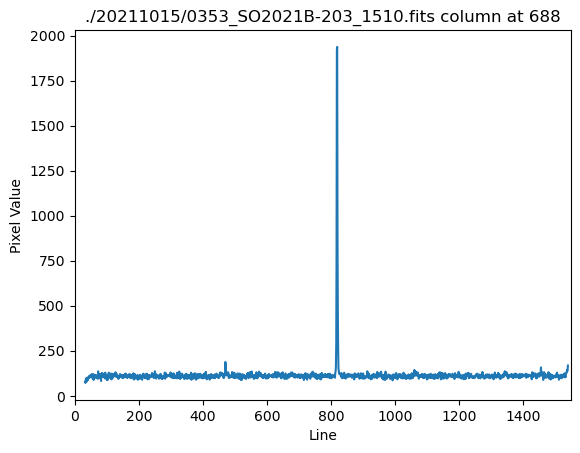

using model: <class 'astropy.modeling.functional_models.Gaussian1D'>
Name: Gaussian1D
N_inputs: 1
N_outputs: 1
Fittable parameters: ('amplitude', 'mean', 'stddev')
xc=687.5345	yc=818.5866
(687,819) mean=   687.59, fwhm=     2.38


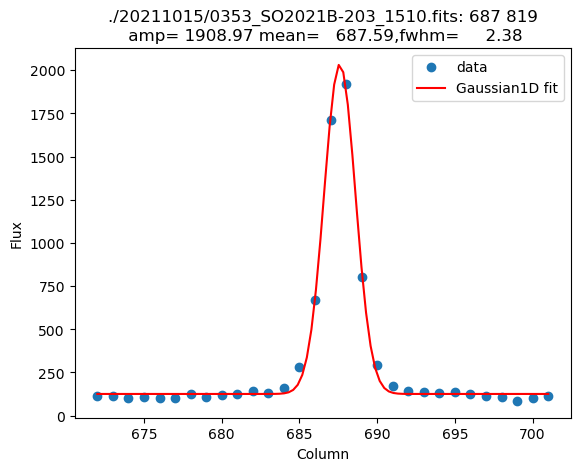

using model: <class 'astropy.modeling.functional_models.Gaussian1D'>
Name: Gaussian1D
N_inputs: 1
N_outputs: 1
Fittable parameters: ('amplitude', 'mean', 'stddev')
xc=687.5345	yc=818.5866
(687,819) mean=   818.63, fwhm=     2.73


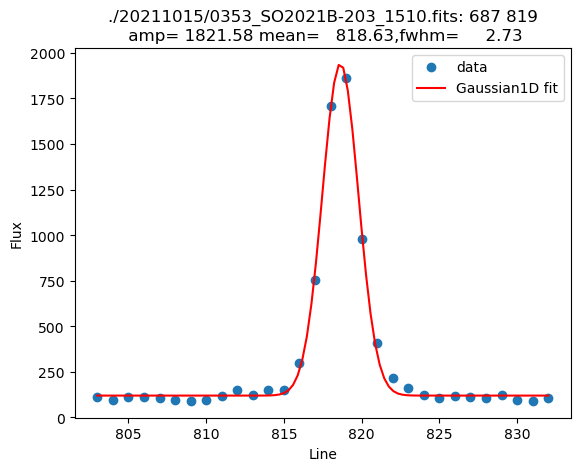

xc=687.5349	yc=818.5860
Background per pixel: 112.4437095762946
Max. pix. flux =  1824.334
amp =  8863.861
fwhm =     4.453


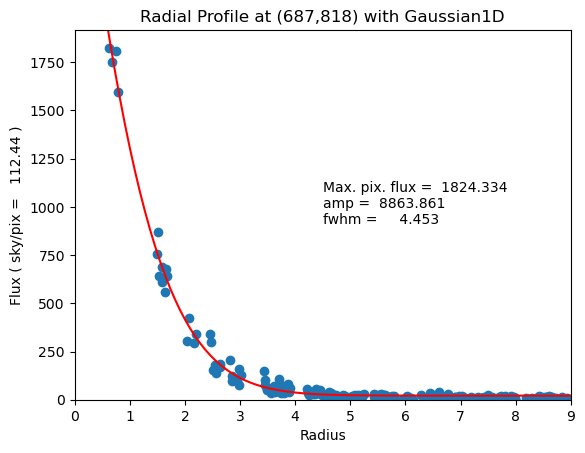

In [3]:
# file = './20210710/SO2021A-002.408.fits'
# file = './20211015/0361_SO2021B-203_1510.fits'
file = './20211015/0353_SO2021B-203_1510.fits'

viewer.load_fits(file)
viewer.scale()
viewer.imexam()